In [ ]:
import pandas as pd
uprise_data = pd.read_excel("/content/drive/MyDrive/uprise all data.xlsx")

In [ ]:
import numpy as np

uprise_data.head(10)

# Standardize 'Crop' column by stripping whitespace and converting to lowercase
uprise_data['Crop'] = uprise_data['Crop'].astype(str).str.strip().str.lower()

# Convert all variations of 'sorghum' (e.g., those starting with 'so') to 'sorghum'
uprise_data['Crop'] = np.where(uprise_data['Crop'].str.startswith('so'), 'sorghum', uprise_data['Crop'])

uprise_data['Crop'].value_counts()

,count
Crop,
maize,322
sorghum,163
millet,120


In [ ]:
df = uprise_data.copy()
# make everything in the daatframe alower
df = df.applymap(lambda s: s.lower() if type(s) == str else s)

# cleaning

df = df.drop(columns=df.columns[28:], axis=1)
df = df.drop(columns='Country.1', axis=1)
#replace sample id column withnid
df.rename(columns={'Country sample ID': 'Id', }, inplace=True)
df.index = df['Id']

print(df.columns)

Index(['Country', 'Id', 'SowingDate', 'SamplingDate', 'TestDate',
       'HarvestDate', 'Awareness', 'Latitude', 'Longitude', 'Region', 'Crop',
       'Variety', 'Color', 'Soil', 'Tillage', 'Fungicide', 'Fertilizer',
       'Seed', 'SowingMethod', 'PrevoiusTime', 'PreviousCrop',
       'Mixed Cropping', 'AFLA (ppb)', 'FUM(ppb)', 'OTA(ppb)', 'ZEA (ppb)',
       'DON (ppb)'],
      dtype='object')


/tmp/ipykernel_534/3759929309.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda s: s.lower() if type(s) == str else s)


In [ ]:
column_map= {'Fungicide': 'Biocide', 'Mixed Cropping': 'Mixcrop', 'Seed': 'Seedprep', 'AFLA (ppb)': 'Afla', 'FUM(ppb)': 'Fum', 'OTA(ppb)': 'Ota', 'ZEA (ppb)': 'Zen',
       'DON (ppb)': 'Don','SowingMethod':'Sowmethod', 'PrevoiusTime':'Prevtime', 'PreviousCrop':'Prevcrop'}

df.rename(columns=column_map, inplace=True)
df.columns

Index(['Country', 'Id', 'SowingDate', 'SamplingDate', 'TestDate',
       'HarvestDate', 'Awareness', 'Latitude', 'Longitude', 'Region', 'Crop',
       'Variety', 'Color', 'Soil', 'Tillage', 'Biocide', 'Fertilizer',
       'Seedprep', 'Sowmethod', 'Prevtime', 'Prevcrop', 'Mixcrop', 'Afla',
       'Fum', 'Ota', 'Zen', 'Don'],
      dtype='object')

In [ ]:
df1= df.drop(columns=['TestDate','Soil','HarvestDate', 'Variety'], axis=1)
#rename sowingdate with harvest column
df1.rename(columns={'SamplingDate': 'HarvestDate'}, inplace=True)
df1.columns
#

Index(['Country', 'Id', 'SowingDate', 'HarvestDate', 'Awareness', 'Latitude',
       'Longitude', 'Region', 'Crop', 'Color', 'Tillage', 'Biocide',
       'Fertilizer', 'Seedprep', 'Sowmethod', 'Prevtime', 'Prevcrop',
       'Mixcrop', 'Afla', 'Fum', 'Ota', 'Zen', 'Don'],
      dtype='object')

                           Afla          Fum       Ota         Zen         Don
Country     Crop                                                              
benin       maize     15.128378   571.133333  0.325333    0.000000    0.000000
            sorghum    1.242222   342.000000  0.426667    0.000000    0.000000
cotedvore   maize     14.607143  6131.250000  0.076471    0.000000    0.000000
            millet     4.916667   413.333333  0.133333    0.000000    0.000000
kenya       maize     25.478571   683.129556  0.324762    0.000000    0.000000
            millet     1.244444    27.674419  0.072093    1.348837  127.906977
            sorghum    8.422727   187.368421  1.477778  251.076923  121.666667
nigeria     maize    195.820588  2142.978723  0.180851   11.063830   42.808511
            millet     2.693182     0.000000  1.057778    0.000000    9.777778
            sorghum   17.600000     0.000000  0.162222    1.088889  213.333333
southafrica maize      0.212308  1108.769231  0.0095

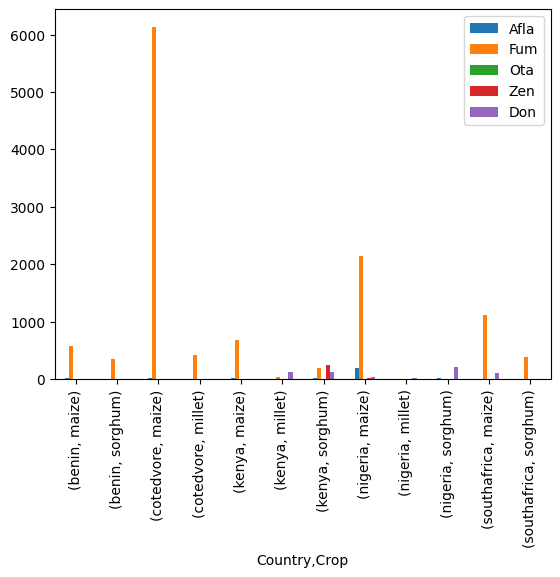

In [ ]:
# Convert relevant columns to numeric, coercing errors will turn non-convertible values into NaN
for col in ['Afla', 'Fum', 'Ota', 'Zen', 'Don']:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

# Now that 'Fum' is guaranteed to be numeric (or NaN), perform the division
#df1['Fum']= df1['Fum']/100

g1=df1.groupby(['Country','Crop'])[['Afla', 'Fum', 'Ota', 'Zen', 'Don']].mean()

print(g1)
plot = g1.plot(kind='bar')

#
print(df1['Country'].value_counts())
print('='*60)
print(df1['Crop'].value_counts())
print('='*60)
print(df1['Awareness'].value_counts())
print('='*60)
print(df1.groupby('Country')[['Region']].value_counts())
print('='*60)
print(df1.groupby(['Crop'])[['Color']].value_counts())
print('='*60)
print(df1.groupby(['Country'])[['Crop']].value_counts())


In [ ]:
import pandas as pd
import re
import calendar

def clean_sowing_date(date_col, is_start=True):

    def parse_date(x):

        if pd.isna(x):
            return pd.NaT

        x = str(x).lower().strip()

        # remove invalid entries
        if x in ["notapplied","n/a","na","none","virgin land",""]:
            return pd.NaT

        # remove descriptive words
        x = re.sub(r'\b(early|mid|late|end|beginning|of)\b', '', x)

        # remove ordinal suffix
        x = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', x)

        # handle ranges (take first part)
        if " - " in x:
            x = x.split(" - ")[0]

        # remove timestamp if present
        x = x.split(" ")[0]

        # convert using pandas
        dt = pd.to_datetime(x, errors='coerce', dayfirst=False)

        if pd.isna(dt):
            return pd.NaT

        # if month-year only (day=1 automatically)
        if dt.day == 1 and re.match(r'^[a-z]{3}-\d{2}$', x):
            if is_start:
                return pd.Timestamp(dt.year, dt.month, 1)
            else:
                last_day = calendar.monthrange(dt.year, dt.month)[1]
                return pd.Timestamp(dt.year, dt.month, last_day)

        return dt

    return date_col.apply(parse_date)

In [ ]:
crop_map = {

# cereals
"maize": "cereal",
"sorghum": "cereal",
"millet": "cereal",
"millet ": "cereal",
" millet": "cereal",
"cereal": "cereal",

# cotton
"cotton": "cottonflower",
"coton": "cottonflower",

# legumes
"soybean": "legume",
"beans": "legume",
"bean": "legume",
"cowpea": "legume",
"cowpeas": "legume",
"peanut": "legume",
"peanuts": "legume",
"legume": "legume",

# tubers
"yam": "tuber",
"cassava": "tuber",
"potatoes": "tuber",
"tuber": "tuber",

# uncultivated / other
"nothing": "uncultivated",
"uncultivated": "uncultivated",
"mix": "mix",
"fruit": "fruit",
"fruits": "fruit",
"sunflower": "cottonflower",
"mellon": "fruit",
"tomatoes": "fruit",
"poultry": "uncultivated"
}

crop_map

{'maize': 'cereal',
 'sorghum': 'cereal',
 'millet': 'cereal',
 'millet ': 'cereal',
 ' millet': 'cereal',
 'cereal': 'cereal',
 'cotton': 'cottonflower',
 'coton': 'cottonflower',
 'soybean': 'legume',
 'beans': 'legume',
 'bean': 'legume',
 'cowpea': 'legume',
 'cowpeas': 'legume',
 'peanut': 'legume',
 'peanuts': 'legume',
 'legume': 'legume',
 'yam': 'tuber',
 'cassava': 'tuber',
 'potatoes': 'tuber',
 'tuber': 'tuber',
 'nothing': 'uncultivated',
 'uncultivated': 'uncultivated',
 'mix': 'mix',
 'fruit': 'fruit',
 'fruits': 'fruit',
 'sunflower': 'cottonflower',
 'mellon': 'fruit',
 'tomatoes': 'fruit',
 'poultry': 'uncultivated'}

In [ ]:

df1['Harvestdate']=clean_sowing_date(df1['HarvestDate'], is_start=False)
df1['Sowdate']=clean_sowing_date(df1['SowingDate'])
# print the harvest date and country column but only row where country is nigeria
print(df1.loc[df1['Country'].str.lower() == 'benin', ['Country', 'Harvestdate','HarvestDate', 'Sowdate','SowingDate']])
df1.drop(columns=['HarvestDate','SowingDate'], inplace=True)
df1.columns
#



/tmp/ipykernel_534/3712960980.py:32: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dt = pd.to_datetime(x, errors='coerce', dayfirst=False)


         Country Harvestdate          HarvestDate    Sowdate  \
Id                                                             
nb-ke1     benin  2024-11-18  2024-11-18 00:00:00 2024-07-10   
sb-ou1     benin  2024-09-11  2024-09-11 00:00:00 2024-03-20   
cb-gl5     benin  2024-12-15  2024-12-15 00:00:00 2024-08-29   
nb-ke9     benin  2024-11-18  2024-11-18 00:00:00 2024-05-28   
nb-d3      benin  2024-11-12  2024-11-12 00:00:00 2024-07-09   
...          ...         ...                  ...        ...   
nb-s-b1    benin  2024-12-29  2024-12-29 00:00:00 2024-07-20   
nb-s-ke5   benin  2024-12-30  2024-12-30 00:00:00 2024-06-21   
sb-ao1     benin  2024-09-11  2024-09-11 00:00:00 2024-04-08   
sb-ao5     benin  2024-12-18  2024-12-18 00:00:00 2024-08-04   
cb-gl3     benin  2024-09-17  2024-09-17 00:00:00 2024-03-03   

                   SowingDate  
Id                             
nb-ke1    2024-07-10 00:00:00  
sb-ou1    2024-03-20 00:00:00  
cb-gl5    2024-08-29 00:00:00  
nb-ke9 

Index(['Country', 'Id', 'Awareness', 'Latitude', 'Longitude', 'Region', 'Crop',
       'Color', 'Tillage', 'Biocide', 'Fertilizer', 'Seedprep', 'Sowmethod',
       'Prevtime', 'Prevcrop', 'Mixcrop', 'Afla', 'Fum', 'Ota', 'Zen', 'Don',
       'Harvestdate', 'Sowdate'],
      dtype='object')

In [ ]:
df1['Prevcrop'].value_counts()

,count
Prevcrop,
cereal,383
legume,85
mix,50
cottonflower,43
tuber,20
uncultivated,19
fruit,5


In [ ]:
df1['Prevcrop']=df1['Prevcrop'].str.lower().str.strip()
#rename prevcrop column items with the crop map
df1['Prevcrop'] = df1['Prevcrop'].replace(crop_map)

df1['Prevcrop'].unique()
for i,j in enumerate(df1['Prevcrop']):
  if j not in ['cereal', 'mix', 'cottonflower', 'legume', 'tuber', 'uncultivated']:
    print(i,j)

311 fruit
351 fruit
377 fruit
424 fruit
428 fruit


In [ ]:
# Replace the item at integer location 21 in 'Prevcrop' column with 'cereal'
df1['Prevcrop'].iloc[21] = 'cereal'
df1['Prevcrop'].iloc[264] = 'cereal'
df1['Prevcrop'].iloc[312] = 'cereal'
df1['Prevcrop'].iloc[373] = 'cereal'
df1['Prevcrop'].iloc[256] = 'legume'

# Verify the change

print(df1['Prevcrop'].value_counts())

Prevcrop
cereal          383
legume           85
mix              50
cottonflower     43
tuber            20
uncultivated     19
fruit             5
Name: count, dtype: int64


/tmp/ipykernel_534/1549447072.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df1['Prevcrop'].iloc[21] = 'cereal'
/tmp/ipykernel_534/1549447072.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [ ]:

df1.columns
df1['Country']

,Country
Id,
nb-ke1,benin
sb-ou1,benin
cb-gl5,benin
nb-ke9,benin
nb-d3,benin
...,...
109,southafrica
127,southafrica
40,southafrica


In [ ]:
# Identify rows for Kenya
kenya_rows_mask = df1['Country'] == 'kenya'

# Temporarily store original 'Latitude' values for Kenya rows
original_kenya_latitude = df1.loc[kenya_rows_mask, 'Latitude'].copy()

# Assign 'Longitude' values to 'Latitude' for Kenya rows
df1.loc[kenya_rows_mask, 'Latitude'] = df1.loc[kenya_rows_mask, 'Longitude']

# Assign original 'Latitude' values to 'Longitude' for Kenya rows
df1.loc[kenya_rows_mask, 'Longitude'] = original_kenya_latitude

print("Columns 'Latitude' and 'Longitude' swapped for Kenya data.")

Columns 'Latitude' and 'Longitude' swapped for Kenya data.


In [ ]:
# Display a sample of the Kenya data to verify the swap
display(df1.loc[kenya_rows_mask, ['Country', 'Latitude', 'Longitude']].head())

,Country,Latitude,Longitude
Id,,,
n,kenya,"(0.13876944444444445, None)","(34.41153611111111, None)"
g,kenya,"(0.3848346, None)","(37.0, None)"
e,kenya,"(0.39031170000000004, None)","(37.7674437, None)"
d,kenya,"(1.701111111111111, None)","(37.407777777777774, None)"
o,kenya,"(0.36898329999999996, None)","(37.777146699999996, None)"


In [ ]:
# Identify rows for Kenya
enya_rows_mask = df1['Country'] == 'southafrica'

# Temporarily store original 'Latitude' values for Kenya rows
riginal_kenya_latitude = df1.loc[enya_rows_mask, 'Latitude'].copy()

# Assign 'Longitude' values to 'Latitude' for Kenya rows
df1.loc[enya_rows_mask, 'Latitude'] = df1.loc[enya_rows_mask, 'Longitude']

# Assign original 'Latitude' values to 'Longitude' for Kenya rows
df1.loc[enya_rows_mask, 'Longitude'] = riginal_kenya_latitude

print("Columns 'Latitude' and 'Longitude' swapped for Kenya data.")
# Display a sample of the Kenya data to verify the swap
display(df1.loc[enya_rows_mask, ['Country', 'Latitude', 'Longitude']].head())


Columns 'Latitude' and 'Longitude' swapped for Kenya data.


,Country,Latitude,Longitude
Id,,,
111,southafrica,27.68915°s,27.52973°e
119,southafrica,28.27039°s,27.09834°e
41,southafrica,22.617697°s,30.576402°e
58,southafrica,22.617419°s,30.557361°e
50,southafrica,22.57300°s,30.57200°e


In [ ]:
len(df1.loc[df1['Country']=='southafrica','Latitude'])

94

In [ ]:
import re

def clean_coordinate(coord):
    if pd.isna(coord):
        return None

    coord = str(coord).strip().replace(',', '.')  # replace comma with decimal point
    coord_upper = coord.upper()  # for consistent hemisphere detection

    # === DMS format: 9°27'28.9'' N or 37*47'3.768"E ===
    dms_match = re.match(r"(\d+)[°*](\d+)['](\d+(?:\.\d+)?)[\"’]? *([NSEWnsew])?", coord_upper)
    if dms_match:
        deg, mins, secs, hemi = dms_match.groups()

        val = float(deg) + float(mins)/60 + float(secs)/3600
        if hemi in ['S', 'W', 's', 'w']:
            val = -val
        return val

    # === Decimal degrees: 10.771847°N ===
    dec_match = re.match(r"([-+]?\d+(?:\.\d+)?)[°]?[ ]*([NSEW])?", coord_upper)
    if dec_match:
        val, hemi = dec_match.groups()
        val = float(val)
        if hemi in ['S', 'W']:
            val = -val
        return val

    # === Fallback: extract first numeric value and apply hemisphere ===
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", coord)
    if nums:
        val = float(nums[0])
        if 'S' in coord_upper or 'W' in coord_upper:
            val = -val
        return val

    # Could not parse
    return None

In [ ]:
import re

def clean_coordinate(coord):
    if pd.isna(coord):
        return None

    coord = str(coord).strip().replace(',', '.')  # replace comma with decimal
    coord_upper = coord.upper()

    # === Detect hemisphere from the last character if it is a letter ===
    hemi = coord_upper[-1] if coord_upper[-1] in ['N', 'S', 'E', 'W'] else None

    # === DMS format: 9°27'28.9'' N or 37*47'3.768"E ===
    dms_match = re.match(r"(\d+)[°*](\d+)['](\d+(?:\.\d+)?)[\"’]?", coord_upper)
    if dms_match:
        deg, mins, secs = dms_match.groups()
        val = float(deg) + float(mins)/60 + float(secs)/3600
        if hemi in ['S', 'W']:
            val = -val
        return val

    # === Decimal degrees: 10.771847°N ===
    dec_match = re.match(r"([-+]?\d+(?:\.\d+)?)[°]?", coord_upper)
    if dec_match:
        val = float(dec_match.groups()[0])
        if hemi in ['S', 'W']:
            val = -val
        return val

    # === Fallback: extract first numeric value and apply hemisphere ===
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", coord_upper)
    if nums:
        val = float(nums[0])
        if hemi in ['S', 'W']:
            val = -val
        return val

    return None

In [ ]:
# CLEAN COORDINATES ##


import pandas as pd
import re


# === Function to clean coordinates ===
def clean_coordinate(coord):
    if pd.isna(coord):
        return None
    # Extract numeric part
    num = re.findall(r"[-+]?\d*\.\d+|\d+", coord)
    if not num:
        return None
    val = float(num[0])

    # Determine sign based on hemisphere
    if "S" in coord.upper() or "W" in coord.upper():
        val = -val
    return val

In [ ]:
df1['Latitude'] = df1['Latitude'].apply(clean_coordinate)
df1['Longitude'] = df1['Longitude'].apply(clean_coordinate)

In [ ]:
df['AFLA (ppb)'].isna().sum()


np.int64(0)

In [ ]:
df1['afla1']=df['AFLA (ppb)']

In [ ]:
print(df1[['Country','Latitude','Longitude']].head(20))
df1['Country'].unique()

         Country   Latitude  Longitude
Id                                    
nb-ke1     benin  10.771847   2.234596
sb-ou1     benin   7.087591   2.509664
cb-gl5     benin   8.215398   2.264457
nb-ke9     benin  10.824477   2.127260
nb-d3      benin   9.630784   1.691513
nb-d4      benin   9.724423   1.787136
nb-n10     benin  10.034433   3.238146
nb-b4      benin  11.379688   2.420120
nb-ke6     benin  10.903788   2.176143
nb-n2      benin  10.034469   3.238261
nb-ke4     benin  10.766911   2.281433
nb-n8      benin   9.947194   3.122171
cb-ou7     benin   8.440767   2.383496
cb-gl4     benin   8.210252   2.269157
nb-ka7     benin  11.392981   3.071796
sb-ou2     benin   7.110598   2.512329
nb-ke8     benin  10.775644   2.218933
nb-s-ke1   benin  10.766913   2.281436
nb-s-d6    benin   9.654539   1.746872
cb-s-ou5   benin   8.508351   2.404303


array(['benin', 'cotedvore', 'kenya', 'nigeria', 'southafrica'],
      dtype=object)

In [ ]:
if 's' in df.loc[df['Country'] == 'kenya', 'Longitude'].astype('str').str.lower().str.split(''):
  print()

yes


In [ ]:
df.loc[df['Country'] == 'kenya', 'Longitude'].str.lower().str.split('')

,Longitude
Id,
n,"[, 0, *, 0, 8, ', 1, 9, ., 5, 7, "", n, ]"
g,"[, 0, *, 2, 3, ', 5, ., 4, 0, 4, 5, 6, "", s, , ]"
e,"[, 0, *, 2, 3, ', 2, 5, ., 1, 2, 2, 1, 2, "", s..."
d,"[, , 1, *, 4, 2, ', 4, "", s, , ]"
o,"[, 0, *, 2, 2, ', 8, ., 3, 3, 9, 8, 8, "", s, ]"
...,...
j,"[, 0, *, 0, 8, ', 0, 3, ., 0, 2, "", n, ]"
d,"[, 0, *, 3, 2, ', 1, 7, ., 0, 6, "", n, ]"
g,"[, 0, *, 3, 1, ', 4, 4, ., 9, 0, "", n, ]"


In [ ]:
if df.loc[df['Country'] == 'kenya', 'Longitude'].astype('str').str.lower().str.contains('s').any():
  df1.loc[df1['Country'] == 'kenya', ['Latitude']] *= -1
  print('yes')

print('Kenya Coordinates:')
print(df1.loc[df1['Country'] == 'kenya', ['Latitude', 'Longitude']].head(26))

yes
Kenya Coordinates:
    Latitude  Longitude
Id                     
n  -0.138769  34.411536
g  -0.384835  37.000000
e  -0.390312  37.767444
d  -1.701111  37.407778
o  -0.368983  37.777147
a  -0.383906  37.786841
r  -0.372807  37.784380
h  -0.529175  35.558819
d  -1.701111  37.407778
g  -0.136978  34.410439
i  -1.705000  37.422778
c  -0.543247  35.549622
b  -0.529594   5.569878
h  -0.137394  34.413056
e  -0.202453  34.250375
l  -0.139286   4.407811
b  -0.269397  34.211028
m  -0.134172  34.414664
y  -0.381491  37.765271
f  -0.137397   4.411842
i  -0.526761  35.553447
p  -0.370202  37.777865
b  -0.390312  37.767444
w  -0.375872  37.801378
a  -0.510739  37.000278
s  -0.372572  37.783977


In [ ]:
df1.loc[df1['Country'] == 'southafrica', ['Latitude']] *= -1
df1.loc[df1['Country'] == 'cotedvore', ['Longitude']] *= -1

print('Kenya Coordinates:')
print(df1.loc[df1['Country'] == 'kenya', ['Latitude', 'Longitude']].head(10))
print('\nSouth Africa Coordinates:')
print(df1.loc[df1['Country'] == 'southafrica', ['Latitude', 'Longitude']].head(10))
print('\nic Coordinates:')
print(df1.loc[df1['Country'] == 'cotedvore', ['Latitude', 'Longitude']].head(20))

Kenya Coordinates:
    Latitude  Longitude
Id                     
n   0.138769  34.411536
g   0.384835  37.000000
e   0.390312  37.767444
d   1.701111  37.407778
o   0.368983  37.777147
a   0.383906  37.786841
r   0.372807  37.784380
h   0.529175  35.558819
d   1.701111  37.407778
g   0.136978  34.410439

South Africa Coordinates:
      Latitude  Longitude
Id                       
111 -27.689150  27.529730
119 -28.270390  27.098340
41  -22.617697  30.576402
58  -22.617419  30.557361
50  -22.573000  30.572000
54  -22.575000  30.557000
69  -22.548835  30.549847
52  -22.575000  30.557000
60  -22.617419  30.557361
125 -28.989783  27.170023

ic Coordinates:
            Latitude  Longitude
Id                             
kr mah 21   9.458028       -5.0
bk mah 17   7.693861       -5.0
kr mah 7    9.458028       -5.0
kr mah 23   9.458028       -5.0
kr mah 9    9.458028       -5.0
kr mah 16   9.458028       -5.0
bk mah 9    7.693861       -5.0
kr mah 24   9.458028       -5.0
tia mah 12  5.898

In [ ]:
df.columns
df1.loc[df1['Country'] == 'cotedvore', ['Harvestdate']] = df.loc[df['Country'] == 'cotedvore', ['SamplingDate']]

In [ ]:
df1.tail(20)
print(df1.loc[df1['Country'] == 'cotedvore', ['Harvestdate']])
df.loc[df['Country'] == 'cotedvore', ['SamplingDate']]

           Harvestdate
Id                    
kr mah 21          NaT
bk mah 17          NaT
kr mah 7           NaT
kr mah 23          NaT
kr mah 9           NaT
...                ...
tia mah 16         NaT
bn mih 8           NaT
bn mih 15          NaT
bn mih 20          NaT
bn mih 28          NaT

[118 rows x 1 columns]


,SamplingDate
Id,
kr mah 21,10-13/12/2024
bk mah 17,15-17/12/2024
kr mah 7,10-13/12/2024
kr mah 23,10-13/12/2024
kr mah 9,10-13/12/2024
...,...
tia mah 16,19-21/12/2024
bn mih 8,21-22/02/2025
bn mih 15,21-22/02/2025


In [ ]:
# sav ethe df1
df1.to_csv('cleaned_2024pa.csv', index=False)

In [ ]:
print(df1.loc[df1['Country']=='kenya', ['Latitude','Longitude']])

    Latitude  Longitude
Id                     
n   0.138769  34.411536
g   0.384835  37.000000
e   0.390312  37.767444
d   1.701111  37.407778
o   0.368983  37.777147
..       ...        ...
j   0.134172  34.414664
d   0.538072  35.548758
g   0.529139  35.559192
d   1.701111  37.407778
k   0.385201  37.852723

[136 rows x 2 columns]


In [ ]:
# get data fro country Benin

benin_data = uprise_data[uprise_data["Country"] == "Benin"]
nigeria_data = uprise_data[uprise_data["Country"] == "Nigeria"]
kenya_data = uprise_data[uprise_data["Country"] == "Kenya"]
southafrica_data = uprise_data[uprise_data["Country"] == "SouthAfrica"]
coteDvore_data = uprise_data[uprise_data["Country"] == "CoteDvore"]



In [ ]:
print(f" kenya = {kenya_data.shape}")
print(f" nigeria = {nigeria_data.shape}")
print(f" southafrica = {southafrica_data.shape}")
print(f" coteDvore = {coteDvore_data.shape}")
print(f" Benin = {benin_data.shape}")

print(f"total = {uprise_data.shape}")
print(f"cummulative = {benin_data.shape[0] + kenya_data.shape[0] + nigeria_data.shape[0] + southafrica_data.shape[0] + coteDvore_data.shape[0]}")



 kenya = (136, 30)
 nigeria = (137, 30)
 southafrica = (94, 30)
 coteDvore = (118, 30)
 Benin = (120, 30)
total = (605, 30)
cummulative = 605


In [ ]:
benin_data['Variety'].value_counts().sum()
benin_data['Variety'].unique()


array(['-', 'Synee 2000', 'QPM/Faaba', 'Carder', ' -', 'EVDT', 'Somba'],
      dtype=object)

In [ ]:
benin_data.info()
print(benin_data)
benin_data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 30 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Country                                             120 non-null    object 
 1   Country sample ID                                   120 non-null    object 
 2   SowingDate                                          120 non-null    object 
 3   SamplingDate                                        120 non-null    object 
 4   TestDate                                            120 non-null    object 
 5   HarvestDate                                         120 non-null    object 
 6   Awareness                                           120 non-null    object 
 7   Latitude                                            120 non-null    object 
 8   Longitude                                           120 non-null    object 
 9   Coun

,Unnamed: 28
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [ ]:
benin_data = benin_data.drop(columns=benin_data.columns[28:], axis=1)

In [ ]:
import requests


In [ ]:
def getweather( lat, lon, start_date, end_date):
  url = "https://power.larc.nasa.gov/api/temporal/daily/point?start={start_date}&end={end_date}&latitude={lat}&longitude={lon}&parmeters=T2M,PRECTOT,RH2M&community=AG&format=JSON"
  response = requests.get (url)
  data = response.json()
  return (data)





In [ ]:
wdata= getweather(25.5300, 28.85775, "20241101", "20250630")


In [ ]:
wdata.keys()



dict_keys(['detail'])

In [ ]:
from tensorflow.keras import Model, layers

In [ ]:

import pandas as pd

dfw = pd.read_csv('/content/2024pw.csv')
dfs = pd.read_csv('/content/2024ps.csv')
dfa = pd.read_csv('/content/cleaned_2024pa.csv')



print(len(dfw))
print(len(dfs))
print(len(dfa))

#dfw.drop(columns=['Harvestdate','Sowdate'], inplace=True)

print(dfw.columns)
print(dfs.columns)
print(dfa.columns)

dfw.fillna(dfw.mean(numeric_only=True), inplace=True)

# remove duplicate coordinates
dfw = dfw.groupby(['Longitude','Latitude']).mean(numeric_only=True).reset_index()
print(len(dfw))
#dfa = dfa.groupby(['Longitude','Latitude']).mean(numeric_only=True).reset_index()


# merge
dfg1 = pd.merge(dfs, dfw, on=['Longitude','Latitude'], how='inner')
print(len(dfg1))

dfg = pd.merge(dfa, dfg1, on=['Longitude','Latitude'], how='inner')

print(dfg.shape)
print(dfg.head())
print(dfg.columns)

dfg.to_csv('2024pg.csv', index=False)

602
298
604
Index(['T2M_s1', 'PRECTOTCORR_s1', 'RH2M_s1', 'ALLSKY_SFC_SW_DWN_s1', 'T2M_s2',
       'PRECTOTCORR_s2', 'RH2M_s2', 'ALLSKY_SFC_SW_DWN_s2', 'T2M_s3',
       'PRECTOTCORR_s3',
       ...
       'RH2M_g29', 'ALLSKY_SFC_SW_DWN_g29', 'T2M_g30', 'PRECTOTCORR_g30',
       'RH2M_g30', 'ALLSKY_SFC_SW_DWN_g30', 'Latitude', 'Longitude', 'Sowdate',
       'Harvestdate'],
      dtype='object', length=380)
Index(['Latitude', 'Longitude', 'ph', 'carbon_organic', 'carbon_total',
       'nitrogen_total', 'cation_exchange_capacity', 'phosphorous_extractable',
       'potassium_extractable', 'calcium_extractable', 'magnesium_extractable',
       'iron_extractable', 'zinc_extractable', 'sulphur_extractable',
       'sand_content', 'silt_content', 'clay_content', 'stone_content',
       'bulk_density'],
      dtype='object')
Index(['Country', 'Id', 'Awareness', 'Latitude', 'Longitude', 'Region', 'Crop',
       'Color', 'Tillage', 'Biocide', 'Fertilizer', 'Seedprep', 'Sowmethod',
       'Prevti

In [ ]:
import requests
import pandas as pd

# === USER INPUT ===
latitude = -25.5300
longitude = 28.85775
start = 20241101
end = 20250630
parameters = ["T2M", "PRECTOTCORR", "RH2M", "ALLSKY_SFC_SW_DWN"]  # Temp, rainfall, humidity, solar radiation

# === API URL ===
url = (
    f"https://power.larc.nasa.gov/api/temporal/daily/point"
    f"?parameters={','.join(parameters)}"
    f"&community=AG"
    f"&longitude={longitude}"
    f"&latitude={latitude}"
    f"&start={start}"
    f"&end={end}"
    f"&format=JSON"
)

# === API REQUEST ===
response = requests.get(url)
data = response.json()

# === EXTRACT DATA ===
records = data["properties"]["parameter"]
df = pd.DataFrame(records)
df = df.transpose()
df.reset_index(inplace=True)
df.rename(columns={'index': 'Date'}, inplace=True)



print(df.head())



                Date  20241101  20241102  20241103  20241104  20241105  \
0                T2M     22.77     25.57     27.06     27.59     24.70   
1        PRECTOTCORR      0.15      0.00      0.00      0.00      0.19   
2               RH2M     49.53     36.74     33.68     26.94     30.05   
3  ALLSKY_SFC_SW_DWN     28.16     27.95     27.75     29.65     19.94   

   20241106  20241107  20241108  20241109  ...  20250621  20250622  20250623  \
0     22.18     22.27     22.76     22.11  ...     10.29      9.63     11.10   
1      0.97      0.25      0.22      0.84  ...      0.00      0.00      0.00   
2     53.06     56.67     54.84     59.43  ...     40.43     72.59     55.95   
3     23.59     16.89     17.61     13.79  ...     16.27     15.05     15.44   

   20250624  20250625  20250626  20250627  20250628  20250629  20250630  
0     11.57     10.43     11.99      7.90      8.06     10.18      9.60  
1      0.00      0.00      0.00      0.00      0.00      0.00      0.00  
2     

In [ ]:
df.to_csv("nasa_weather_.csv", index=False)
print("✅ Data saved to nasa_power_weather_data.csv")

✅ Data saved to nasa_power_weather_data.csv


In [ ]:
data["properties"]


{'parameter': {'T2M': {'20241101': 22.77,
   '20241102': 25.57,
   '20241103': 27.06,
   '20241104': 27.59,
   '20241105': 24.7,
   '20241106': 22.18,
   '20241107': 22.27,
   '20241108': 22.76,
   '20241109': 22.11,
   '20241110': 20.76,
   '20241111': 19.24,
   '20241112': 19.01,
   '20241113': 22.36,
   '20241114': 20.48,
   '20241115': 20.89,
   '20241116': 23.76,
   '20241117': 24.99,
   '20241118': 25.16,
   '20241119': 26.05,
   '20241120': 24.8,
   '20241121': 26.0,
   '20241122': 23.78,
   '20241123': 25.52,
   '20241124': 24.09,
   '20241125': 24.74,
   '20241126': 25.87,
   '20241127': 25.86,
   '20241128': 22.16,
   '20241129': 19.63,
   '20241130': 21.01,
   '20241201': 23.63,
   '20241202': 25.55,
   '20241203': 26.98,
   '20241204': 28.79,
   '20241205': 28.77,
   '20241206': 29.47,
   '20241207': 27.6,
   '20241208': 26.77,
   '20241209': 26.37,
   '20241210': 28.51,
   '20241211': 25.88,
   '20241212': 28.26,
   '20241213': 29.2,
   '20241214': 26.31,
   '20241215': 24

In [ ]:
param_info = data['properties']['parameterInformation']
print(param_info['T2M']['longname'], "-", param_info['T2M']['units'])

KeyError: 'parameterInformation'

In [ ]:
sites = pd.read_csv("/content/UPRISE Data Collection_v.csv", encoding='latin-1')

In [ ]:
sites.head()

In [ ]:
sites['Lat'] = sites['Longitude']
sites['Lon'] = sites['Latitude']
sites.iloc[:10,:]

In [ ]:
## CLEAN DATES ##


import pandas as pd
import calendar
from datetime import datetime

# === Helper function to convert mixed month-year strings ===
def convert_to_date(date_str, is_start=True):
    if pd.isna(date_str) or str(date_str).strip() in ["NotApplied", "", "nan"]:
        return pd.NaT

    date_str = str(date_str).strip()

    # Try both common patterns
    for fmt in ("%b-%y", "%y-%b", "%d-%b", "%b-%d"):
        try:
            date = datetime.strptime(date_str, fmt)
            break
        except ValueError:
            continue
    else:
        print(f" Could not parse date: {date_str}")
        return pd.NaT

    # If parsed only month & year (no day), assign start or end of month
    if date.day == 1 and fmt in ("%b-%y", "%y-%b"):
        if is_start:
            return pd.Timestamp(date.year, date.month, 1)
        else:
            last_day = calendar.monthrange(date.year, date.month)[1]
            return pd.Timestamp(date.year, date.month, last_day)

    # Otherwise, return parsed full date
    return pd.Timestamp(date)

# === Apply conversions ===
sites["sowing_start"] = sites["SowingDate"].apply(lambda x: convert_to_date(x, is_start=True))
sites["harvest_end"] = sites["HarvestDate"].apply(lambda x: convert_to_date(x, is_start=False))

# === Example Output ===
print(sites[["SowingDate", "sowing_start", "HarvestDate", "harvest_end"]].head())


In [ ]:
## CLEAN COORDINATES ##


import pandas as pd
import re


# === Function to clean coordinates ===
def clean_coordinate(coord):
    if pd.isna(coord):
        return None
    # Extract numeric part
    num = re.findall(r"[-+]?\d*\.\d+|\d+", coord)
    if not num:
        return None
    val = float(num[0])

    # Determine sign based on hemisphere
    if "S" in coord.upper() or "W" in coord.upper():
        val = -val
    return val

# === Apply the cleaning ===
#sites["longitude_clean"] = benin_data["Longitude"].apply(clean_coordinate)
#sites["latitude_clean"] = benin_data["Latitude"].apply(clean_coordinate)

lon = benin_data["Longitude"].apply(clean_coordinate)
lat = benin_data["Latitude"].apply(clean_coordinate)

print(lon)
print(lat)
#
# The following line caused the error by trying to convert a Series to a single Timestamp.
# If the goal was to convert the column, use pd.to_datetime. If to print one value, pick an element.
# print(pd.Timestamp(benin_data['SowingDate']))


In [ ]:
site_ubset=['latitude_clean', 'longitude_clean', 'sowing_start', 'harvest_end']

In [ ]:
sites[site_ubset]

In [ ]:
new_sites[site_ubset]

In [ ]:
import pandas as pd
import requests
import time
from tqdm import tqdm
import numpy as np

# === Keep only unique rows ===
new_sites = sites.drop_duplicates(
    subset=['latitude_clean', 'longitude_clean', 'sowing_start', 'harvest_end']
).reset_index(drop=True)
print(f"✅ Unique sites to fetch: {len(new_sites)}")

parameters = ["T2M", "PRECTOTCORR", "RH2M", "ALLSKY_SFC_SW_DWN"]

all_data = []

def fetch_nasa_power(lat, lon, start, end):

    if pd.isna(lat) or pd.isna(lon) or pd.isna(start) or pd.isna(end):
        return None

    start_str = start.strftime('%Y%m%d')
    end_str = end.strftime('%Y%m%d')

    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters={','.join(parameters)}"
        f"&community=AG"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={start_str}"
        f"&end={end_str}"
        f"&format=JSON"
    )

    try:
        response = requests.get(url, timeout=60)
        data = response.json()

        if "properties" not in data or "parameter" not in data["properties"]:
            return None

        params = data["properties"]["parameter"]

        # Convert to a DataFrame of daily values
        daily_df = pd.DataFrame(params).T
        daily_df.index = pd.to_datetime(daily_df.index, format='%Y%m%d')
        daily_df = daily_df.sort_index()

        # 🟦 WEEKLY AGGREGATION: Sum over each 7-day block
        weekly_df = daily_df.resample("W").sum()   # change to .mean() if needed

        # 🟧 RENAME COLUMNS: T2M_wk1, T2M_wk2, etc.
        weekly_df.columns = [
            f"{col}_wk{i+1}" for col in weekly_df.columns for i in range(len(weekly_df))
        ][:len(weekly_df.columns) * len(weekly_df)]

        # Fix column naming
        new_cols = {}
        for col in weekly_df.columns:
            base, wk = col.split("_wk")
            # create week index based on actual column order
            if base not in new_cols:
                new_cols[base] = 1
            new_val = f"{base}_wk{new_cols[base]}"
            new_cols[base] += 1
            weekly_df.rename(columns={col: new_val}, inplace=True)

        # Flatten to one row
        flat_row = {"latitude": lat, "longitude": lon, "sowing_start": start, "harvest_end": end}
        flat_row.update(weekly_df.to_dict("records")[0])  # add week values

        return flat_row

    except Exception as e:
        print(f"❌ Error: {e}")
        return None


# === Retrieve for all sites ===
for idx, row in tqdm(new_sites.iterrows(), total=len(new_sites)):
    lat, lon = row["latitude_clean"], row["longitude_clean"]
    start, end = row["sowing_start"], row["harvest_end"]

    data_row = fetch_nasa_power(lat, lon, start, end)

    if data_row:
        all_data.append(data_row)
        print(f"✅ Site {idx+1}/{len(new_sites)} downloaded.")

    time.sleep(2)  # NASA rate limit


# === Save output ===
if all_data:
    final_df = pd.DataFrame(all_data)
    final_df.to_csv("All_Sites_WeatherData_WEEKLY.csv", index=False)
    print("🎉 Weekly aggregated dataset saved: All_Sites_WeatherData_WEEKLY.csv")
else:
    print("⚠️ No data retrieved.")


In [ ]:
## RETRIEVE WEATHER DATA ##


import pandas as pd
import requests
import time
from tqdm import tqdm

# === Keep only unique rows based on lat, lon, start, end ===
new_sites = sites.drop_duplicates(
    subset=['latitude_clean', 'longitude_clean', 'sowing_start', 'harvest_end']
).reset_index(drop=True)
print(f"✅ Unique sites to fetch: {len(new_sites)}")

# === Define weather parameters ===
parameters = ["T2M","PRECTOTCORR", "RH2M", "ALLSKY_SFC_SW_DWN"]

# === Container for all flattened rows ===
all_data = []

def fetch_nasa_power(lat, lon, start, end):
    """Fetch and flatten NASA POWER weather data for one site into a single-row dict"""
    if pd.isna(lat) or pd.isna(lon) or pd.isna(start) or pd.isna(end):
        print(f"⚠️ Missing lat/lon or dates for ({lat}, {lon})")
        return None

    # Format dates
    start_str = start.strftime('%Y%m%d')
    end_str = end.strftime('%Y%m%d')

    # === Construct API URL ===
    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters={','.join(parameters)}"
        f"&community=AG"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={start_str}"
        f"&end={end_str}"
        f"&format=JSON"
    )

    try:
        response = requests.get(url, timeout=60)
        data = response.json()

        if "properties" not in data or "parameter" not in data["properties"]:
            print(f"⚠️ No data for ({lat}, {lon}) from {start_str} to {end_str}.")
            return None

        # === Extract data ===
        params = data["properties"]["parameter"]

        # === Flatten the daily data into one row ===
        flat_row = {
            "latitude": lat,
            "longitude": lon,
            "sowing_start": start,
            "harvest_end": end
        }

        for param, date_values in params.items():
            for date_str, value in date_values.items():
                flat_row[f"{param}_{date_str}"] = value

        return flat_row

    except Exception as e:
        print(f"❌ Error fetching data for ({lat}, {lon}) from {start_str} to {end_str}: {e}")
        return None


# === Loop through each site and collect flattened rows ===
for idx, row in new_sites.iterrows():
    lat = row["latitude_clean"]
    lon = row["longitude_clean"]
    start = row["sowing_start"]
    end = row["harvest_end"]

    data_row = fetch_nasa_power(lat, lon, start, end)
    if data_row:
        all_data.append(data_row)
        print(f"✅ Added site {idx+1}/{len(new_sites)}: ({lat}, {lon})")

    time.sleep(2)  # Respect NASA POWER rate limit


# === Combine all into one DataFrame and save ===
if all_data:
    final_df = pd.DataFrame(all_data)
    output_file = "All_Sites_WeatherData.csv"
    final_df.to_csv(output_file, index=False)
    print(f"\n✅ All data saved successfully: {output_file}")
else:
    print("\n⚠️ No data retrieved.")


In [ ]:
## SOIL DATA RETRIEVAL ##


import pandas as pd
import requests
import time
from tqdm import tqdm

# === API details ===
base_url = "https://api.isda-africa.com"
username = "mohammed.merhdie@gmail.com"
password = "P13bs1019"

# === Authenticate to get token ===
payload = {"username": username, "password": password}
response = requests.post(f"{base_url}/login", data=payload)

if response.status_code != 200:
    raise Exception(f"❌ Login failed: {response.text}")

access_token = response.json().get("access_token")
if not access_token:
    raise Exception("❌ No access token returned. Check credentials.")

headers = {"Authorization": f"Bearer {access_token}"}

# === Soil properties to request ===
soil_properties = [
    # Soil chemical properties
    "ph",                           # pH
    "carbon_organic",               # Organic carbon (SOC)
    "carbon_total",                 # Total carbon
    "nitrogen_total",               # Total nitrogen
    "cation_exchange_capacity",     # Effective CEC
    "phosphorous_extractable",      # Available phosphorus
    "potassium_extractable",        # Available potassium
    "calcium_extractable",          # Available calcium
    "magnesium_extractable",        # Available magnesium
    "iron_extractable",             # Available iron
    "zinc_extractable",             # Available zinc
    "sulphur_extractable",          # Available sulphur

    # Soil physical properties
    "sand_content",                 # % Sand
    "silt_content",                 # % Silt
    "clay_content",                 # % Clay
    "stone_content",                # % Stones
    "bulk_density",                 # g/cm³, affects aeration
]


depth = "0-20"  # cm layer
soil_data = []

# === Remove duplicate sites ===
unique_sites = sites.drop_duplicates(subset=["latitude_clean", "longitude_clean"]).reset_index(drop=True)
print(f"✅ Fetching soil data for {len(unique_sites)} unique sites")


# === Loop through each coordinate ===
for idx, row in unique_sites.iterrows():
    lat = row["latitude_clean"]
    lon = row["longitude_clean"]

    site_info = {"latitude": lat, "longitude": lon}

    # === Retrieve each soil property ===
    for prop in soil_properties:
        try:
            url = f"{base_url}/isdasoil/v2/soilproperty?lat={lat}&lon={lon}&property={prop}&depth={depth}"
            r = requests.get(url, headers=headers, timeout=60)

            if r.status_code == 200:
                data = r.json()
                if "property" in data and prop in data["property"]:
                    value = data["property"][prop][0]["value"]["value"]
                    site_info[prop] = value
                else:
                    site_info[prop] = None
            else:
                print(f"⚠️ {prop} failed for ({lat},{lon}) → {r.status_code} -skipping")
                site_info[prop] = None
                continue

            time.sleep(3)  # prevent hitting rate limits

        except Exception as e:
            print(f"❌ Error fetching {prop} for ({lat},{lon}): {e}")
            site_info[prop] = None

    soil_data.append(site_info)

# === Combine into DataFrame and save ===
soil_df = pd.DataFrame(soil_data)
soil_df.to_csv("ISDA_Soil_Data_AllSites.csv", index=False)
print("✅ Soil data saved to ISDA_Soil_Data_AllSites.csv")


In [ ]:
import pandas as pd
df = pd.read_csv('/content/cleaned_2024pa.csv')

In [ ]:
import pandas as pd
import requests
import time
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# =========================
# API DETAILS
# =========================

base_url = "https://api.isda-africa.com"

username = "mohammed.merhdie@gmail.com"
password = "P13bs1019"

payload = {"username": username, "password": password}

response = requests.post(f"{base_url}/login", data=payload)

if response.status_code != 200:
    raise Exception(f"Login failed: {response.text}")

access_token = response.json().get("access_token")

headers = {"Authorization": f"Bearer {access_token}"}

print("Login successful")

# =========================
# SOIL VARIABLES
# =========================

soil_properties = [

    "ph",
    "carbon_organic",
    "carbon_total",
    "nitrogen_total",
    "cation_exchange_capacity",
    "phosphorous_extractable",
    "potassium_extractable",
    "calcium_extractable",
    "magnesium_extractable",
    "iron_extractable",
    "zinc_extractable",
    "sulphur_extractable",

    "sand_content",
    "silt_content",
    "clay_content",
    "stone_content",
    "bulk_density",
]

depth = "0-20"

# =========================
# UNIQUE LOCATIONS
# =========================

unique_sites = df[["Latitude", "Longitude"]].drop_duplicates().reset_index(drop=True)

print(f"Fetching soil data for {len(unique_sites)} locations")

# =========================
# FUNCTION TO FETCH SOIL DATA
# =========================

def fetch_soil(lat, lon):

    site_data = {
        "Latitude": lat,
        "Longitude": lon
    }

    for prop in soil_properties:

        retries = 3

        for attempt in range(retries):

            try:

                url = (
                    f"{base_url}/isdasoil/v2/soilproperty?"
                    f"lat={lat}&lon={lon}&property={prop}&depth={depth}"
                )

                r = requests.get(url, headers=headers, timeout=15)

                if r.status_code == 200:

                    data = r.json()

                    if "property" in data and prop in data["property"]:

                        value = data["property"][prop][0]["value"]["value"]
                        site_data[prop] = value
                        break

                    else:
                        site_data[prop] = None
                        break

                else:
                    time.sleep(1)

            except Exception:
                time.sleep(1)

        else:
            site_data[prop] = None

    # small pause to avoid API bursts
    time.sleep(0.1)

    return site_data


# =========================
# PARALLEL DOWNLOAD
# =========================

soil_rows = []

with ThreadPoolExecutor(max_workers=6) as executor:

    futures = [
        executor.submit(fetch_soil, row.Latitude, row.Longitude)
        for row in unique_sites.itertuples(index=False)
    ]

    for future in tqdm(as_completed(futures), total=len(futures)):
        soil_rows.append(future.result())


# =========================
# CREATE DATAFRAME
# =========================

soil_df = pd.DataFrame(soil_rows)

print("Soil download finished")

# =========================
# SAVE SOIL DATA
# =========================

soil_df.to_csv("2024ps.csv", index=False)

print("Soil data saved")


# ===

Login successful
Fetching soil data for 298 locations


100%|██████████| 298/298 [09:26<00:00,  1.90s/it]

Soil download finished
Soil data saved


In [ ]:
# fill missing soil values base on spatial interpolation

import pandas as pd
soil_df = pd.read_csv('/content/2024ps.csv')
import pandas as pd
import numpy as np
from scipy.spatial import KDTree

# Columns that contain soil variables
soil_cols = [
    "ph","carbon_organic","carbon_total","nitrogen_total",
    "cation_exchange_capacity","phosphorous_extractable",
    "potassium_extractable","calcium_extractable",
    "magnesium_extractable","iron_extractable",
    "zinc_extractable","sulphur_extractable",
    "sand_content","silt_content","clay_content",
    "stone_content","bulk_density"
]

# Coordinates
coords = soil_df[["Latitude","Longitude"]].values

# Build KDTree
tree = KDTree(coords)

# Loop through each soil variable
for col in soil_cols:

    # rows with missing values
    missing = soil_df[col].isna()

    if missing.sum() == 0:
        continue

    # rows with known values
    known_points = soil_df.loc[~missing, ["Latitude","Longitude"]].values
    known_values = soil_df.loc[~missing, col].values

    # build KDTree for known points
    known_tree = KDTree(known_points)

    # coordinates needing interpolation
    missing_points = soil_df.loc[missing, ["Latitude","Longitude"]].values

    # find nearest neighbour
    dist, idx = known_tree.query(missing_points, k=1)

    # assign nearest value
    soil_df.loc[missing, col] = known_values[idx]

print("Spatial interpolation completed.")
print(soil_df.isna().sum())
soil_df.to_csv("2024ps.csv", index=False)

Spatial interpolation completed.
Latitude                    0
Longitude                   0
ph                          0
carbon_organic              0
carbon_total                0
nitrogen_total              0
cation_exchange_capacity    0
phosphorous_extractable     0
potassium_extractable       0
calcium_extractable         0
magnesium_extractable       0
iron_extractable            0
zinc_extractable            0
sulphur_extractable         0
sand_content                0
silt_content                0
clay_content                0
stone_content               0
bulk_density                0
dtype: int64


In [ ]:
import pandas as pd
import requests
import time
from tqdm import tqdm
import numpy as np

parameters = ["T2M", "PRECTOTCORR", "RH2M", "ALLSKY_SFC_SW_DWN"]

def fetch_nasa_power(lat, lon, sow, harvest):

    if pd.isna(lat) or pd.isna(lon) or pd.isna(sow) or pd.isna(harvest):
        return None

    # fetch wider window to cover all needed days
    start = sow - pd.Timedelta(days=5)
    end = harvest

    start_str = start.strftime('%Y%m%d')
    end_str = end.strftime('%Y%m%d')

    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters={','.join(parameters)}"
        f"&community=AG"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={start_str}"
        f"&end={end_str}"
        f"&format=JSON"
    )

    try:

        r = requests.get(url, timeout=60)
        data = r.json()

        params = data["properties"]["parameter"]

        daily = pd.DataFrame(params)
        daily.index = pd.to_datetime(daily.index, format="%Y%m%d")
        daily = daily.sort_index()

        row_out = {}

        # ===============================
        # 1️⃣ SOWING WINDOW (-3 → +30 days)
        # ===============================
        sow_window = daily.loc[sow - pd.Timedelta(days=3): sow + pd.Timedelta(days=30)]

        for i, (_, day) in enumerate(sow_window.iterrows(), start=1):
            for p in parameters:
                row_out[f"{p}_s{i}"] = day[p]

        # ===============================
        # 2️⃣ HARVEST WINDOW (-30 → 0)
        # ===============================
        harvest_window = daily.loc[harvest - pd.Timedelta(days=29): harvest]

        for i, (_, day) in enumerate(harvest_window.iterrows(), start=1):
            for p in parameters:
                row_out[f"{p}_h{i}"] = day[p]

        # ===============================
        # 3️⃣ MIDDLE GROWTH WINDOW
        # ===============================
        mid_start = sow + pd.Timedelta(days=31)
        mid_end = harvest - pd.Timedelta(days=31)

        mid = daily.loc[mid_start:mid_end]

        if len(mid) > 0:

            segments = np.array_split(mid, 30)

            for i, seg in enumerate(segments, start=1):

                for p in parameters:

                    row_out[f"{p}_g{i}"] = seg[p].mean()

        return row_out

    except Exception as e:
        print("Error:", e)
        return None


# ===================================
# LOOP THROUGH OBSERVATIONS
# ===================================

weather_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df)):

    lat = row["Latitude"]
    lon = row["Longitude"]
    sow = pd.to_datetime(row["Sowdate"])
    har = pd.to_datetime(row["Harvestdate"])

    data = fetch_nasa_power(lat, lon, sow, har)

    if data:
        data["Latitude"] = lat
        data["Longitude"] = lon
        data["Sowdate"] = sow
        data["Harvestdate"] = har

        weather_rows.append(data)

    time.sleep(1)

weather_df = pd.DataFrame(weather_rows)

weather_df.to_csv("2024pw.csv", index=False)

print("✅ Weather features generated.")

  0%|          | 0/604 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
  0%|          | 1/604 [00:01<19:21,  1.93s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
  0%|          | 2/604 [00:03<17:29,  1.74s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
  0%|          | 3/604 [00:05<18:18,  1.83s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecat

Error: 'properties'


 94%|█████████▍| 567/604 [17:37<00:59,  1.62s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
 94%|█████████▍| 568/604 [17:38<00:58,  1.63s/it]

Error: 'properties'


 94%|█████████▍| 569/604 [17:40<00:56,  1.60s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
 94%|█████████▍| 570/604 [17:41<00:54,  1.61s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
 95%|█████████▍| 571/604 [17:44<00:57,  1.75s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
 95%|█████████▍| 572/604 [17:46<00:59,  1.85s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapa

✅ Weather features generated.


In [ ]:
import requests

username = "mohammed.merhdie@gmail.com"
password = "P13bs1019"

base_url = "https://api.isda-africa.com"

# First call the login endpoint to get the access token. Token expiry: 60 minutes
payload = {"username": username, "password": password}
response = requests.post(f"{base_url}/login", data=payload)

# Check if login was successful
if response.status_code == 200:
    access_token = response.json().get("access_token")

    if access_token:
        # Then use the access token to call the soilproperty endpoint. Get the ph value for a location in Kenya at 0-20cm depth.
        headers = {"Authorization": f"Bearer {access_token}"}
        response = requests.get(
            f"{base_url}/isdasoil/v2/soilproperty?lat=-0.7196&lon=35.2400&property=ph&depth=0-20",
            headers=headers,
        )

        # Check if the soil data request was successful
        if response.status_code == 200:
            response_data = response.json()

            # Check if 'property' key exists before accessing it
            if 'property' in response_data and 'ph' in response_data['property']:
                print(f"ph value: {response_data['property']['ph'][0]['value']['value']}"
                    f" (uncertainty: {response_data['property']['ph'][0]['uncertainty'][1]['lower_bound']}-"
                    f"{response_data['property']['ph'][0]['uncertainty'][1]['upper_bound']})")
            else:
                print("Error: 'property' or 'ph' key not found in the soil data response.")
                print(f"Soil data response: {response_data}")
        else:
            print(f"Error fetching soil data: API returned status code {response.status_code}")
            print(f"Soil data response text: {response.text}")
    else:
        print("Error: Access token not found in the login response.")
        print(f"Login response: {response.json()}")
else:
    print(f"Error logging in to the API: API returned status code {response.status_code}")
    print(f"Login response text: {response.text}")

In [ ]:
import requests
import pandas as pd

# --- Coordinates ---
latitude = -1.2921     # example: Nairobi, Kenya
longitude = 36.8219

# --- Define soil properties to retrieve ---
properties = ["clay", "sand", "silt", "phh2o", "nitrogen", "soc", "cec"]
depths = ["0-5cm", "5-15cm", "15-30cm"]

# --- Build API URL ---
url = (
    f"https://rest.isric.org/soilgrids/v2.0/properties/query?"
    f"lon={longitude}&lat={latitude}"
    f"&property={','.join(properties)}"
    f"&depth={','.join(depths)}&value=mean"
)

# --- Fetch data ---
response = requests.get(url)

# --- Check for successful response before parsing JSON ---
if response.status_code != 200:
    print(f"Error: API returned status code {response.status_code}")
    print(f"Response text: {response.text}")
else:
    try:
        data = response.json()

        # --- Flatten the data into a dictionary ---
        flat = {"latitude": latitude, "longitude": longitude}

        for layer in data["properties"]["layers"]:
            prop = layer["name"]
            for d in layer["depths"]:
                depth_label = d["label"].replace(" ", "").replace("-", "_")
                flat[f"{prop}_{depth_label}"] = d["values"]["mean"]

        # --- Display as DataFrame ---
        df = pd.DataFrame([flat])
        print(df.T)

    except requests.exceptions.JSONDecodeError as e:
        print(f"Error decoding JSON: {e}")
        print(f"Response text: {response.text}")

In [ ]:
!pip install azure-ai-ml

from azure.ai.ml import MLClient

In [ ]:
from google.colab import drive
drive.mount('/content/drive')